# Predicción de Emisiones de CO2 haciendo uso de algoritmos de Machine Learning como Linear Regression

Objetivo: El objetivo de este proyecto es realizar un EDA para preparar los datos para un modelo de aprendizaje automático, centrándose en la construcción de un modelo lineal.

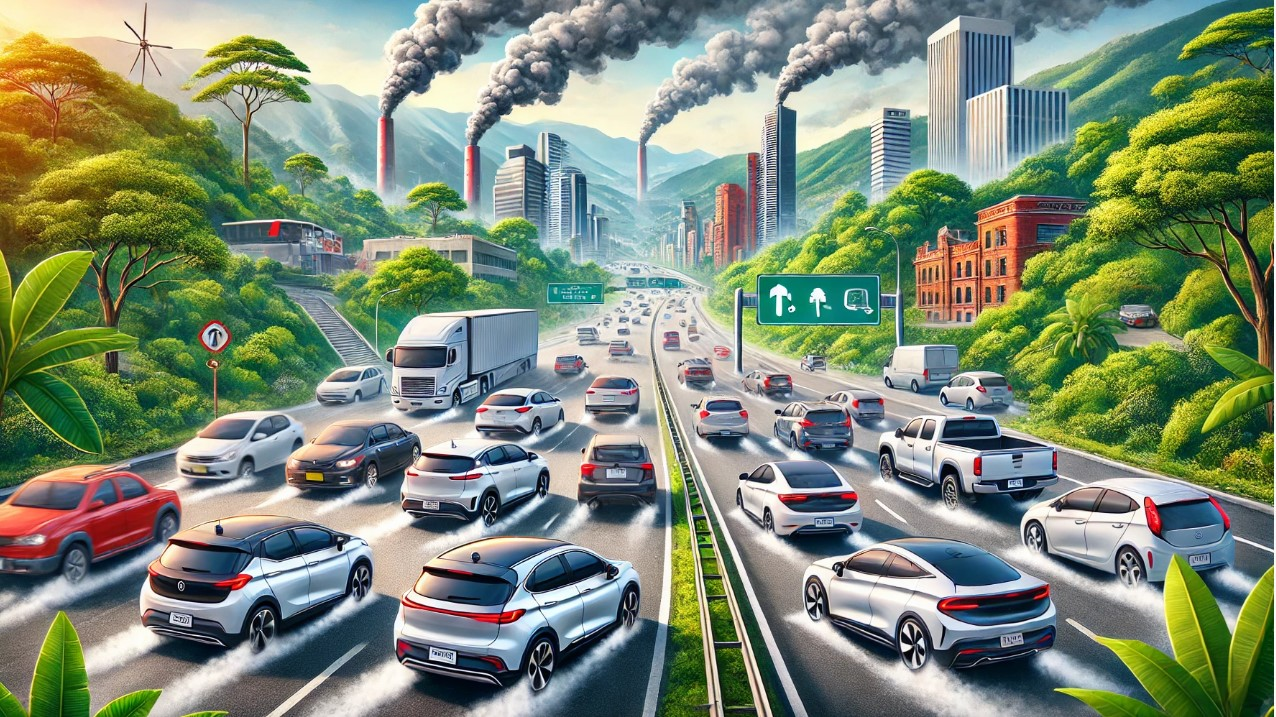

# PIPELINE ALGORITMOS DE REGRESIÓN

# 1. PIPELINE/RECOLECCIÓN DE DATOS

1. Importar y Leer el DataSet

In [82]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import scipy.stats as stats

from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score, cross_validate

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from yellowbrick.regressor import ResidualsPlot, PredictionError

import warnings
warnings.filterwarnings("ignore")

In [4]:
co2 = pd.read_csv('Data/Emissions_Canada_CO2.csv')
# Hacer una copia del DataSet original
df = co2.copy()

# 2. PIPELINE/ANÁLISIS EXPLORATORIO DE DATOS (EDA)





# Comprendiendo los Datos

In [5]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [6]:
# Mostrar 5 filas de manera aleatoria
df.sample(5)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
1383,CHRYSLER,300 FFV,FULL-SIZE,3.6,6,A8,E,16.8,10.3,13.9,20,222
5819,FORD,Transit Connect Van,SPECIAL PURPOSE VEHICLE,2.0,4,AS8,X,9.8,8.8,9.3,30,219
3291,VOLVO,S60 T5 AWD,COMPACT,2.5,5,AS6,X,11.6,8.2,10.1,28,233
513,HYUNDAI,SONATA,FULL-SIZE,2.0,4,A6,X,11.4,7.5,9.6,29,221
3933,KIA,NIRO,STATION WAGON - SMALL,1.6,4,AM6,X,4.6,5.1,4.8,59,114


In [7]:
# Conocer en Detalle la estructura del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [8]:
# Calculemos cuanto datos nulos hay, y mostremos un porcentaje de esos datos nulos si se encuentran presentes
missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"Cuantos Nulos": missing_count, "Porcentaje": missing_percentage})
missing_df

,Cuantos Nulos,Porcentaje
Make,0,0.0
Model,0,0.0
Vehicle Class,0,0.0
Engine Size(L),0,0.0
Cylinders,0,0.0
Transmission,0,0.0
Fuel Type,0,0.0
Fuel Consumption City (L/100 km),0,0.0
Fuel Consumption Hwy (L/100 km),0,0.0
Fuel Consumption Comb (L/100 km),0,0.0


Las columnas Engine Size(L), Cylinders, Fuel Consumption City (L/100 km), Fuel Consumption Hwy (L/100 km), Fuel Consumption Comb (L/100 km), Fuel Consumption Comb (mpg) and CO2 Emissions(g/km) son numericas  y continuas.
</p>
Las Columnas Make, Model, Vehicle Class, Transmission and Fuel Type son categoricas.

In [9]:
# Estadisticas Básicas que se pueden aplicar a las columnas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [10]:
# Renombrar las columnas
df.rename(columns={ 'Make': 'make',
                    'Model': 'model',
                    'Vehicle Class': 'vehicle_class',
                    'Engine Size(L)': 'engine_size',
                    'Cylinders': 'cylinders',
                    'Transmission': 'transmission',
                    'Fuel Type': 'fuel_type',
                    'Fuel Consumption City (L/100 km)': 'fuel_cons_city',
                    'Fuel Consumption Hwy (L/100 km)': 'fuel_cons_hwy',
                    'Fuel Consumption Comb (L/100 km)': 'fuel_cons_comb',
                    'Fuel Consumption Comb (mpg)': 'fuel_cons_comb_mpg',
                    'CO2 Emissions(g/km)': 'co2'
                    }, inplace=True)

In [11]:
# Mostrar las nuevas columnas renombradas
df.columns

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_cons_city', 'fuel_cons_hwy',
       'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2'],
      dtype='object')

# Data Visualización

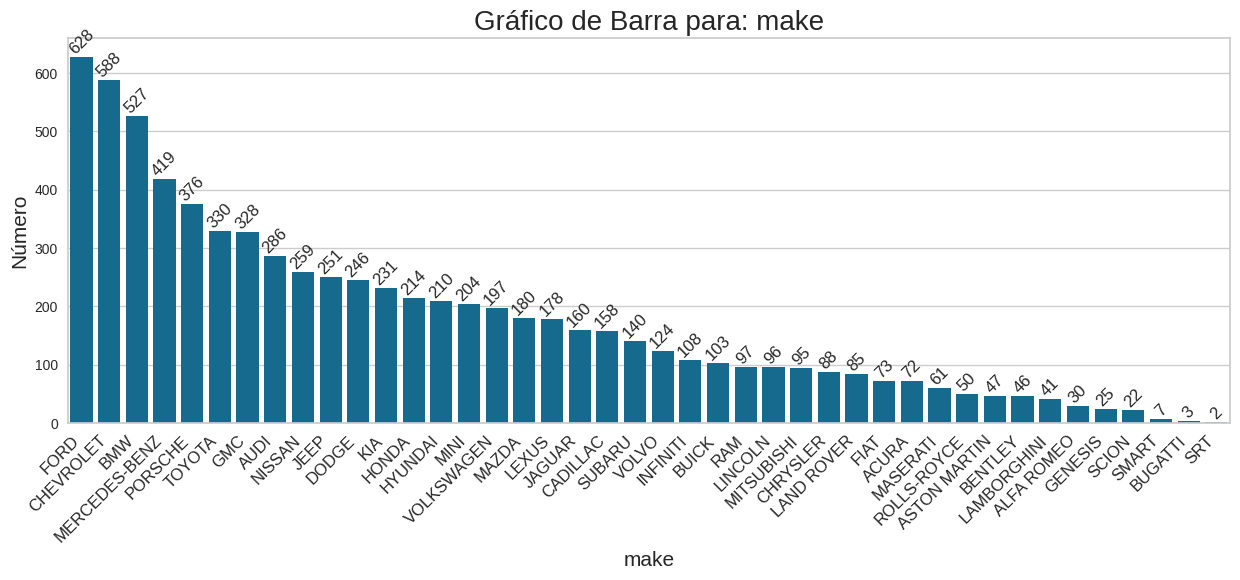

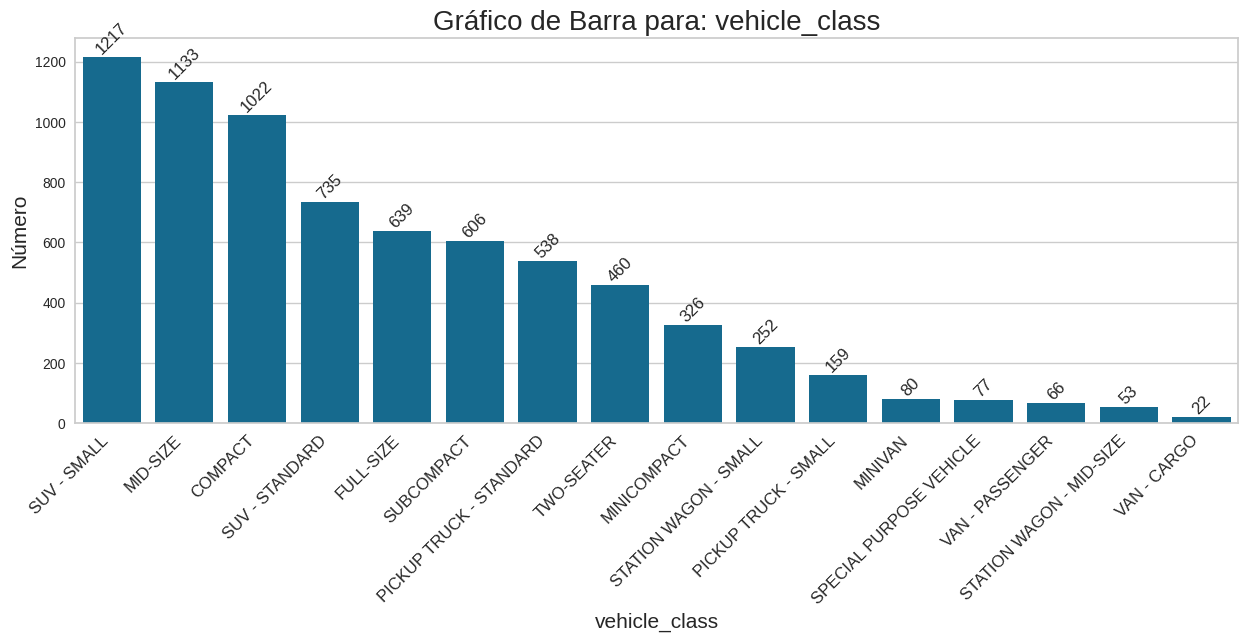

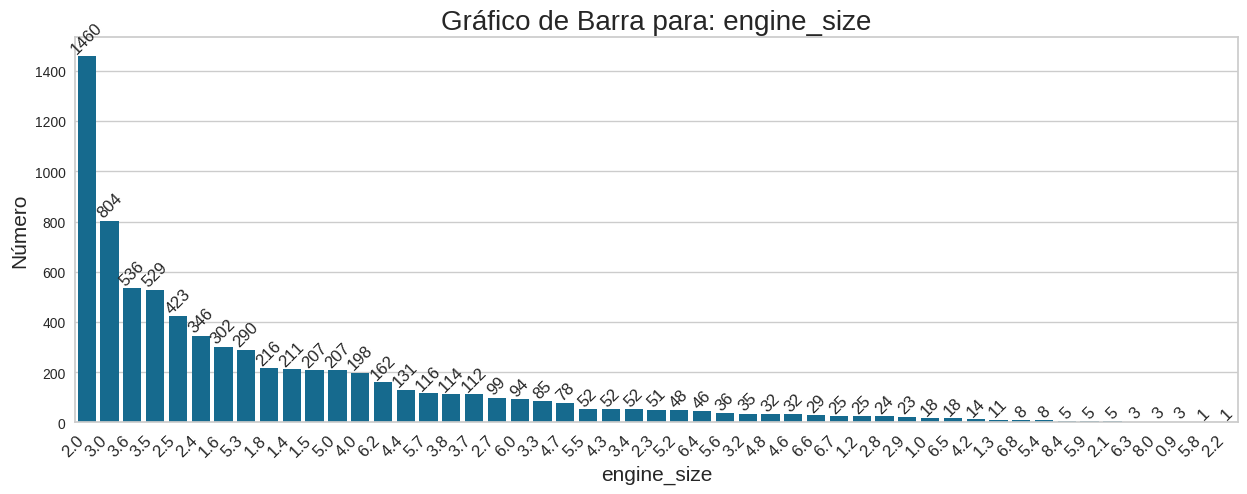

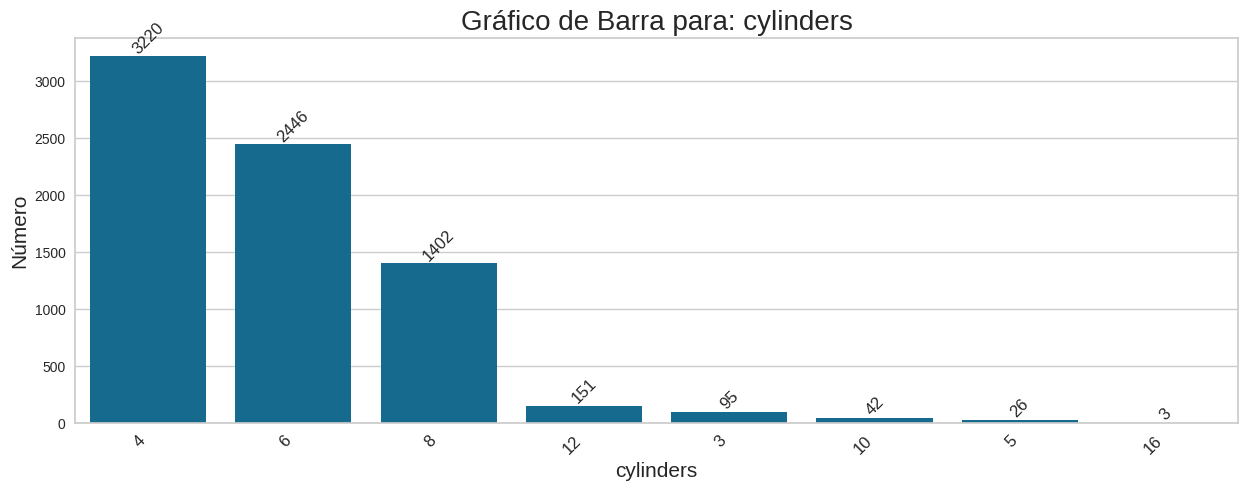

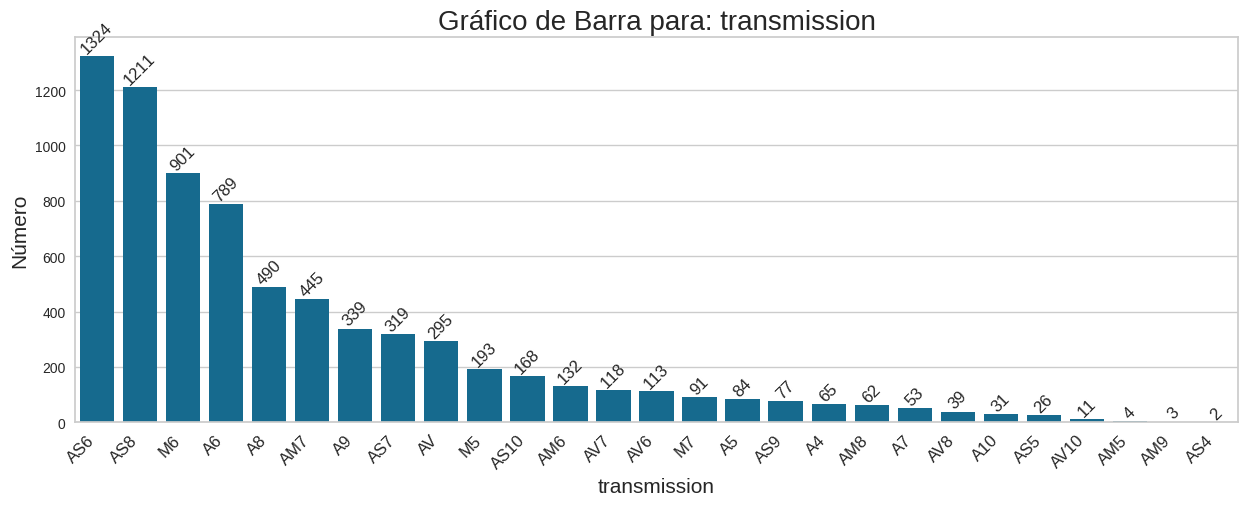

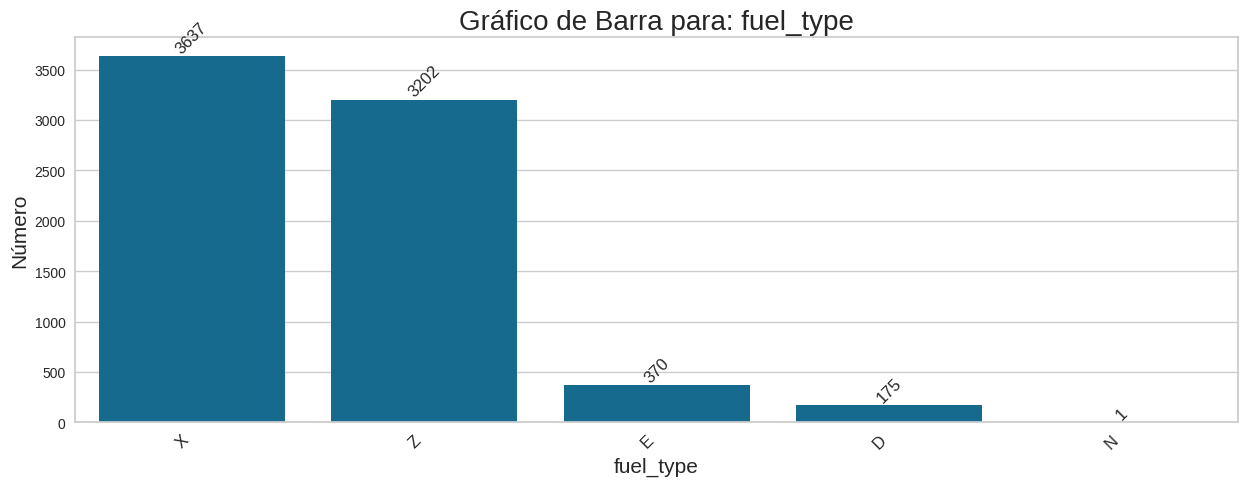

In [12]:
# Observemos a continuacion como estan distribuidas las columnas categoricas haciendo uso de graficos de barra
import plotly.graph_objects as go
import plotly.express as px

def plot_bar_graphs(df, columns):
    for column in columns:
        plt.figure(figsize=(15, 5))
        ax = sns.countplot(x=column, data=df, order=df[column].value_counts().index)
        ax.bar_label(ax.containers[0],rotation=45)
        plt.xlabel(column, fontsize=15)
        plt.ylabel('Número', fontsize=15)
        plt.title(f'Gráfico de Barra para: {column}', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.show()

cat_features = ['make','vehicle_class', 'engine_size', 'cylinders', 'transmission', 'fuel_type']

plot_bar_graphs(df, cat_features)

# Análicemos nuestra variable objetivo frente a las demás caracteristicas

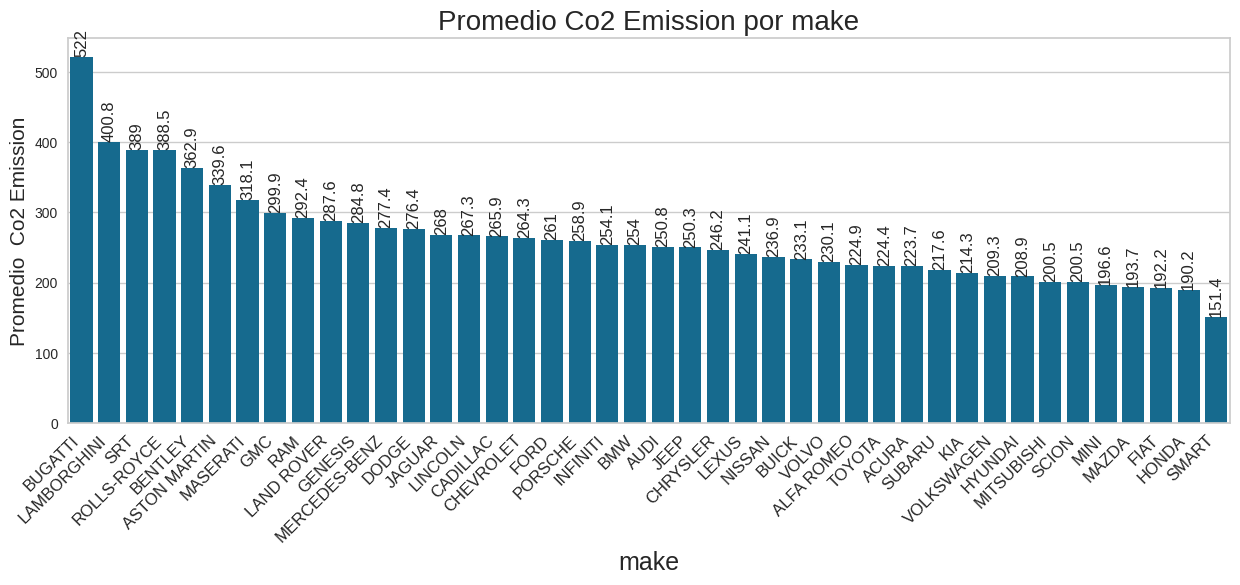

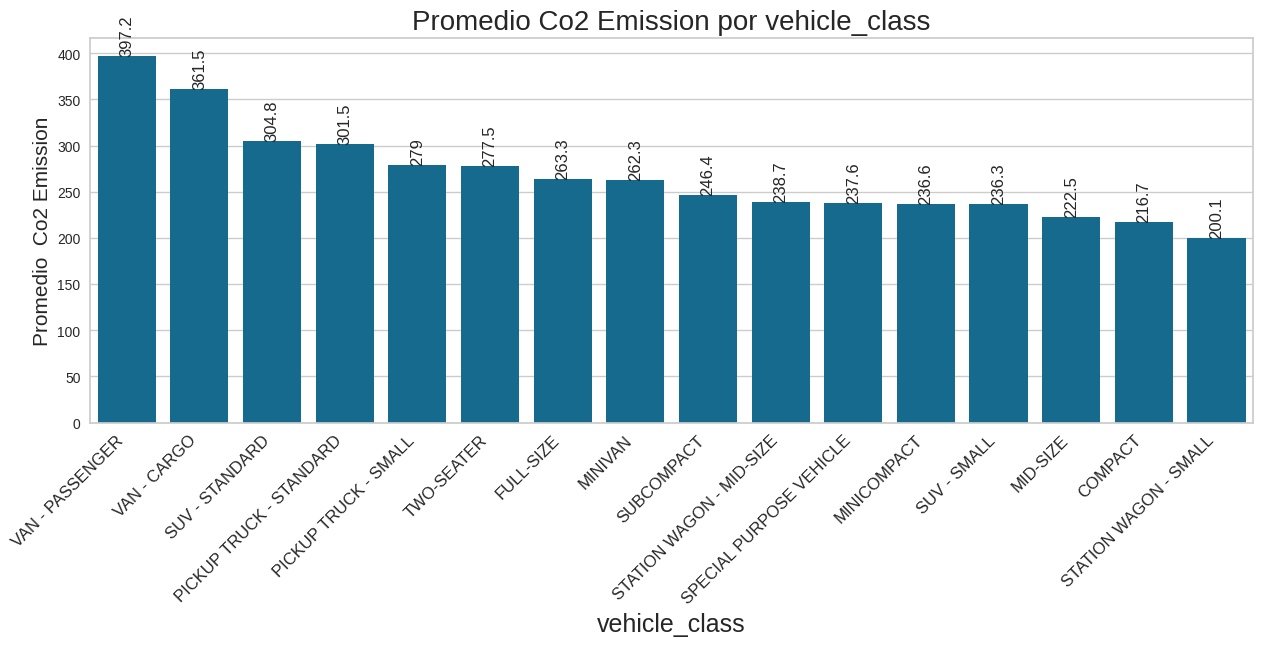

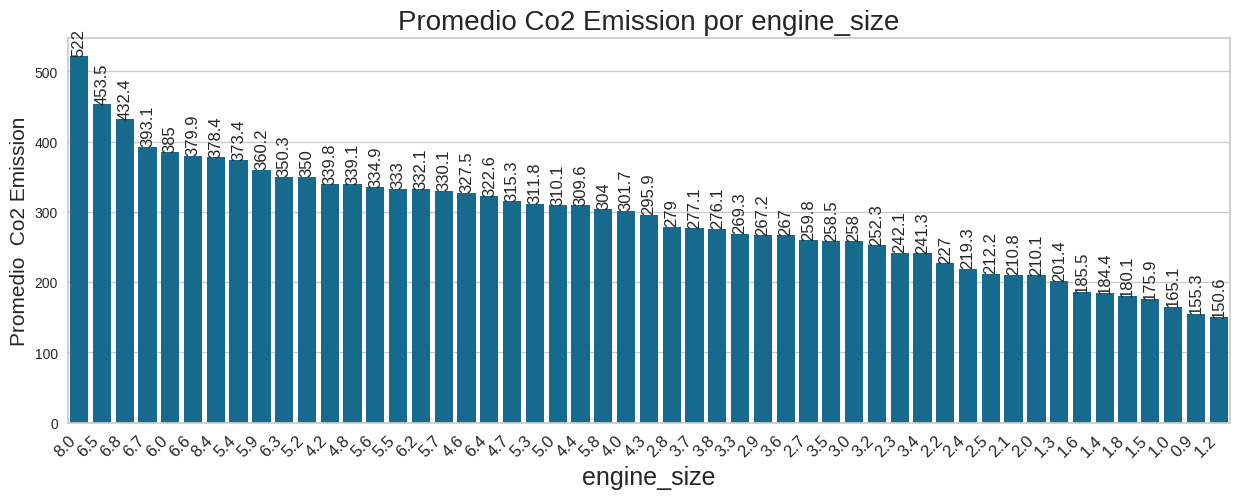

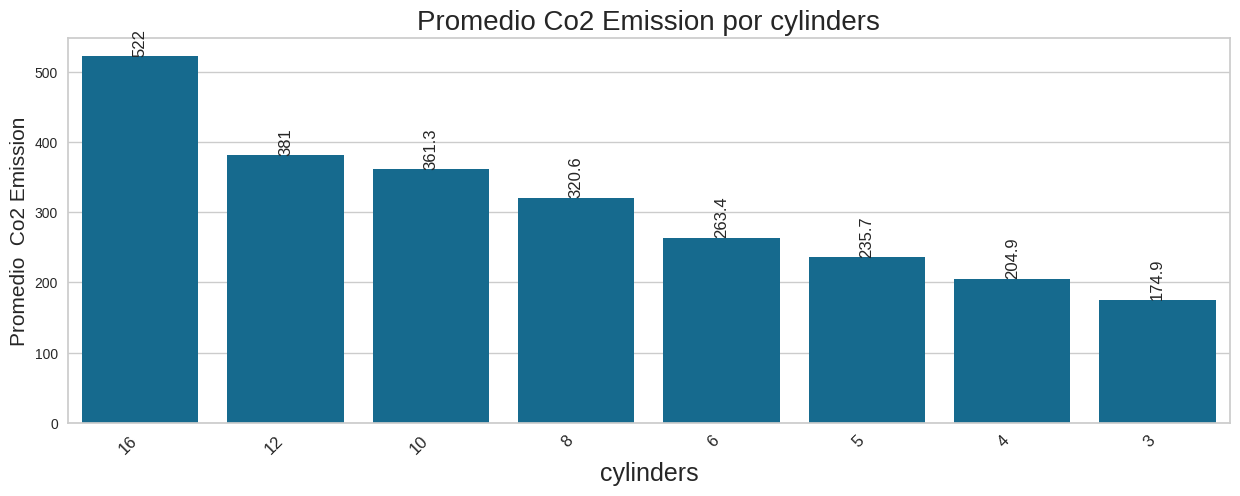

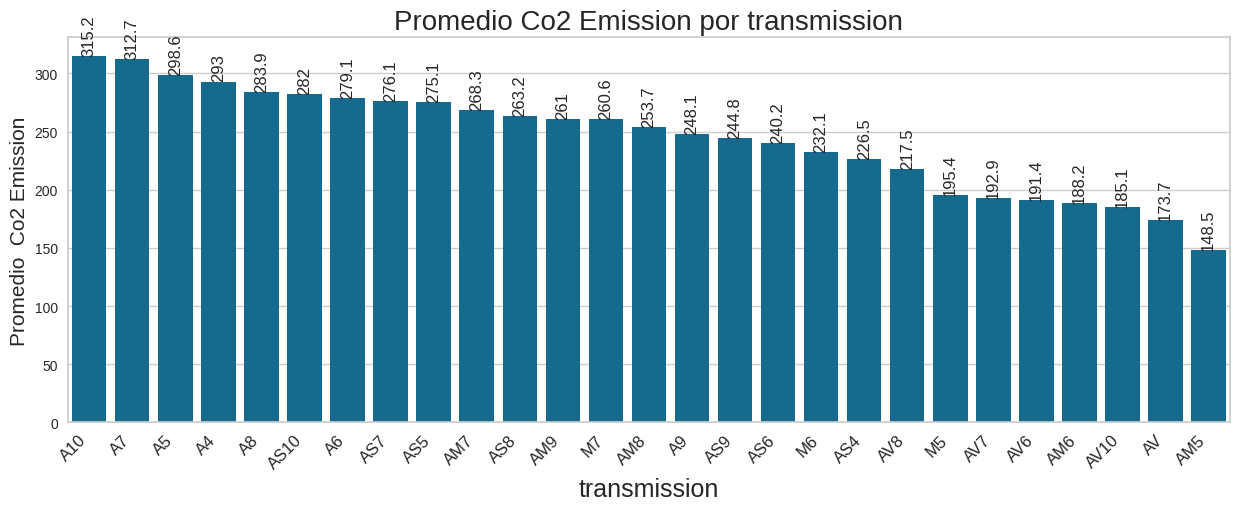

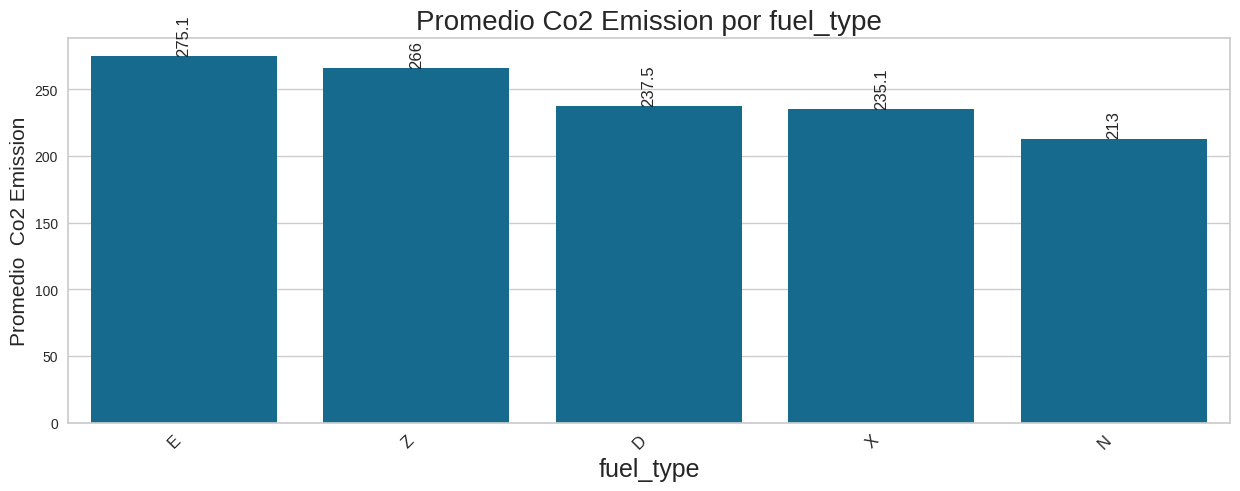

In [ ]:
def plot_bar_with_co2(df, columns):
    for column in columns:
        plt.figure(figsize=(15, 5))
        grouped_data = df.groupby(column)['co2'].mean().round(1).reset_index()
        grouped_data_sorted = grouped_data.sort_values(by='co2', ascending=False)
        ax = sns.barplot(x=column, y='co2', data=grouped_data_sorted, order=grouped_data_sorted[column])
        ax.bar_label(ax.containers[0],rotation=90)
        plt.xlabel(column, fontsize=18)
        plt.ylabel('Promedio  Co2 Emission', fontsize=15)
        plt.title(f'Promedio Co2 Emission por {column}', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.show()

plot_bar_with_co2(df, cat_features)

# Conclusiones de los gráficos observados anteriormente:

Como se puede ver en los gráficos anteriores:



*   Bugatti tiene las emisiones medias de CO2 más altas
*   Los vehículos de gran volumen tienen medias de emisiones de CO2 altas
*   Las medias de emisiones de CO2 de los motores de gran volumen y cilindros también son altas.
*   El etanol es el combustible con la media más alta de emisiones de CO2









# Aplicar Encoding a las características categóricas

In [13]:
from sklearn.preprocessing import LabelEncoder
# Copiar el dataset para evitar modificar el original directamente
df_labeled = df.copy()

# Listar las columnas categóricas
categorical_columns = ['make', 'model', 'vehicle_class', 'transmission', 'fuel_type']

# Aplicar Label Encoding para cada columna categórica
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    df_labeled[column] = le.fit_transform(df_labeled[column])
    label_encoders[column] = le

# Mostrar las primeras filas del Dataframe codificado(encoded)
#print(df_labeled.head())
df_labeled.head()

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
0,0,1057,0,2.0,4,14,4,9.9,6.7,8.5,33,196
1,0,1057,0,2.4,4,25,4,11.2,7.7,9.6,29,221
2,0,1058,0,1.5,4,22,4,6.0,5.8,5.9,48,136
3,0,1233,11,3.5,6,15,4,12.7,9.1,11.1,25,255
4,0,1499,11,3.5,6,15,4,12.1,8.7,10.6,27,244


# Qué Observamos? Cómo funciona el Label Encoder?

Tu respuesta Aqui Campista...

In [14]:
# Imprimimos la información del DataSet codificado (encoded)
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make                7385 non-null   int64  
 1   model               7385 non-null   int64  
 2   vehicle_class       7385 non-null   int64  
 3   engine_size         7385 non-null   float64
 4   cylinders           7385 non-null   int64  
 5   transmission        7385 non-null   int64  
 6   fuel_type           7385 non-null   int64  
 7   fuel_cons_city      7385 non-null   float64
 8   fuel_cons_hwy       7385 non-null   float64
 9   fuel_cons_comb      7385 non-null   float64
 10  fuel_cons_comb_mpg  7385 non-null   int64  
 11  co2                 7385 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 692.5 KB


# Creamos la Matriz de Correlación

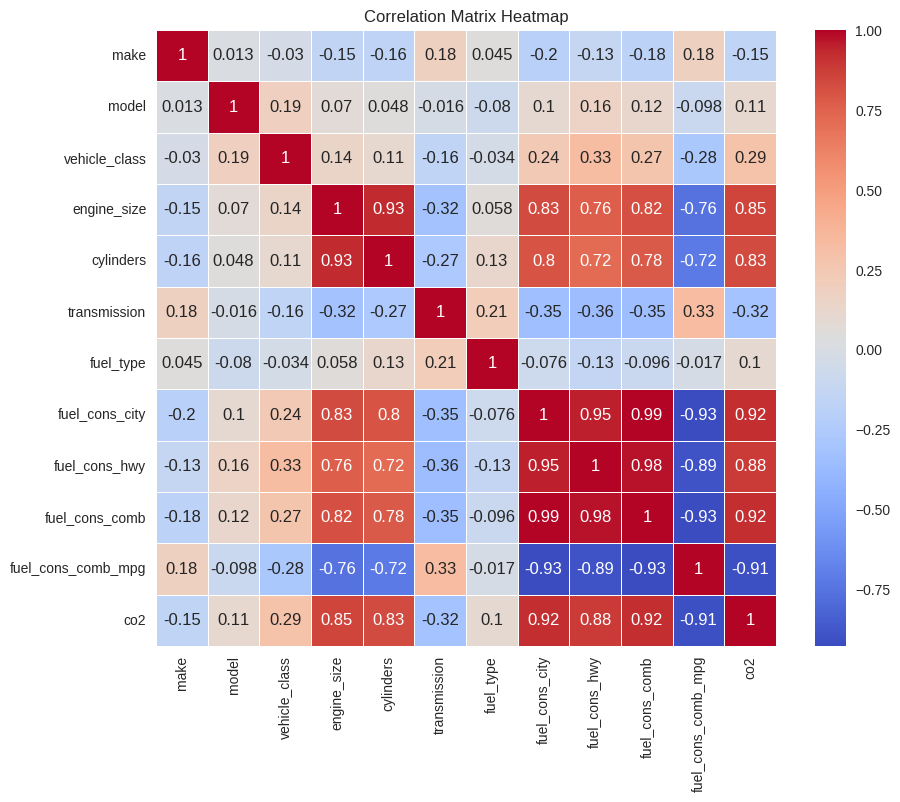

In [15]:
correlation_matrix = df_labeled.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Observaciones:

* La matriz de correlación muestra que características como el tamaño del motor, los cilindros y las métricas de consumo de combustible (ciudad, carretera, combinado) tienen fuertes correlaciones positivas con las emisiones de co2.

* En particular, fuel_cons_mpg tiene una fuerte correlación negativa con las emisiones de CO2, lo que indica que una mayor eficiencia del combustible da como resultado menores emisiones.

* Desde una perspectiva de multicolinealidad, fuel_cons_city, fuel_cons_hwy y fuel_cons_comb están altamente intercorrelacionados, lo que sugiere una posible redundancia.

* Puede resultar beneficioso seleccionar solo uno o combinarlos en una única métrica para evitar la multicolinealidad.
Los predictores clave para un modelo de emisiones de CO2 incluyen el tamaño del motor, los cilindros y las métricas de consumo de combustible.

* Las características categóricas como marca, modelo, clase de vehículo, transmisión y tipo de combustible también son importantes debido a su impacto significativo en las emisiones de CO2.

* Gestionar la multicolinealidad entre estas características altamente correlacionadas es crucial para garantizar la estabilidad y el rendimiento del modelo.

# Tratamiento para las caracteristicas numéricas

# Distribución para las caracteristicas numéricas:



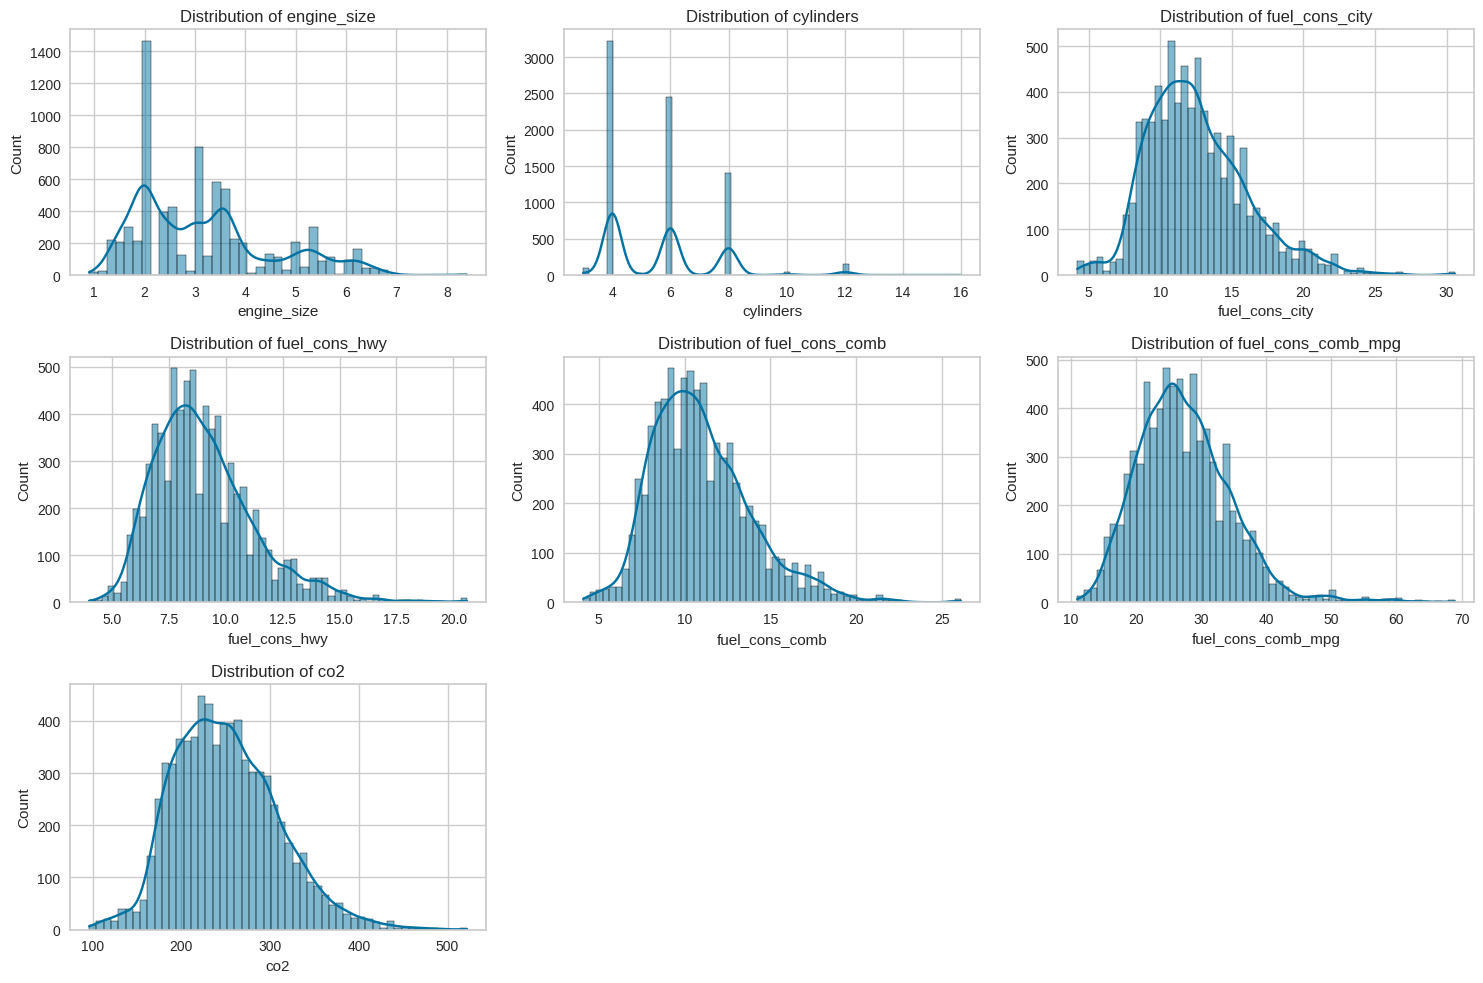

In [16]:
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(15, 10))

num_vars = len(numerical_df.columns)

for i, var in enumerate(numerical_df.columns, 1):
    plt.subplot((num_vars // 3) + 1, 3, i)
    sns.histplot(data=df, x=var, kde=True)
    plt.title(f'Distribution of {var}')

plt.tight_layout()
plt.show()

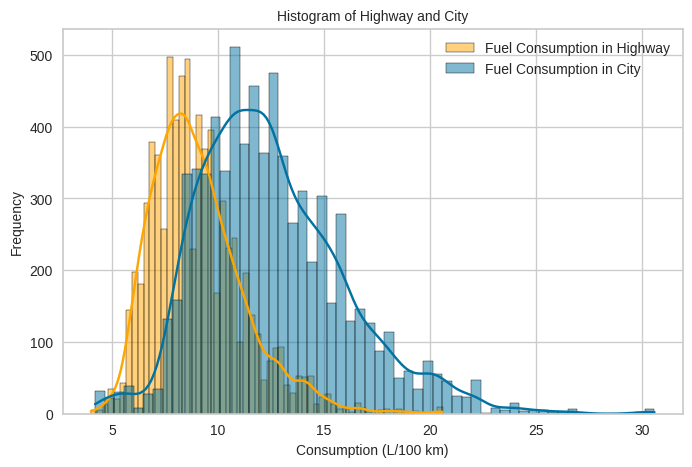

In [17]:
# Consumo de gasolina en el highway con relación al total de gasolina consumido en la Ciudad

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fuel_cons_hwy", kde=True, label = "Fuel Consumption in Highway",color = "orange")
sns.histplot(data=df, x="fuel_cons_city", kde=True, label = "Fuel Consumption in City")
plt.xlabel('Consumption (L/100 km)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title(f'Histogram of Highway and City', fontsize=10)
plt.legend()
plt.show()

# Conclusiones generales de los graficos de distribucion normal generados:

La mayoría de las características exhiben distribuciones normales o sesgadas, que son adecuadas para modelar.

Considere la multicolinealidad, especialmente entre fuel_cons_City, fuel_cons_Hwy y fuel_cons_Comb.

Características como cilindros, tamaño del motor y combustible_cons_mpg brindan información importante sobre el rendimiento y la eficiencia del vehículo, lo que las hace valiosas para el modelo.

# Matriz de Correlación para las caracteristicas numéricas

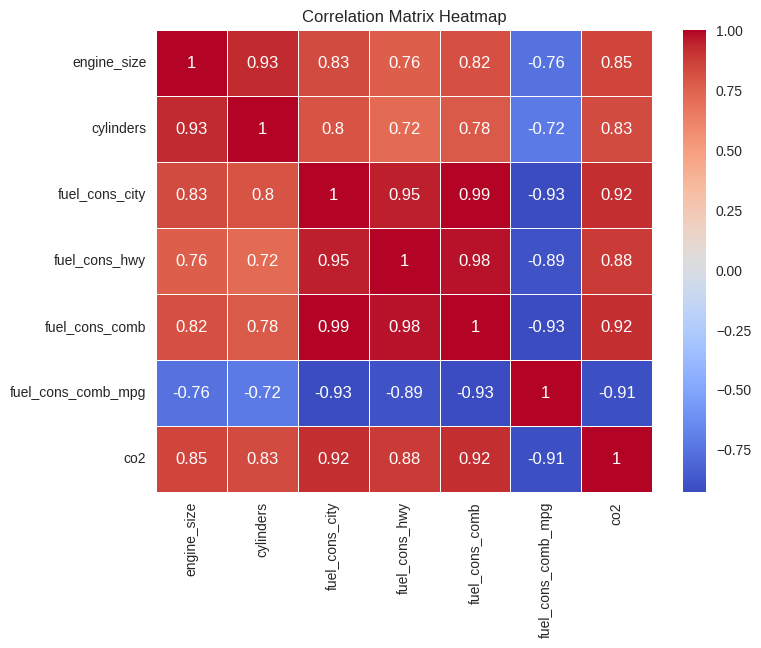

In [18]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Conclusión Importante:

Estos hallazgos sugieren que eliminar algunas características altamente correlacionadas puede ayudar a reducir la multicolinealidad y mejorar el rendimiento del modelo.

Formas de solucionarla:

1. Eliminar una de las variables correlacionadas: Si dos variables contienen información redundante, puedes elegir quedarte con una.
2. Usar técnicas de reducción de dimensionalidad: Métodos como PCA (Análisis de Componentes Principales) pueden combinar variables correlacionadas en una sola.
3. Regularización: Técnicas como Ridge Regression o Lasso pueden manejar multicolinealidad al penalizar los coeficientes del modelo.


# Formas de visualizar las correlaciones entre las variables independientes y variable dependiente

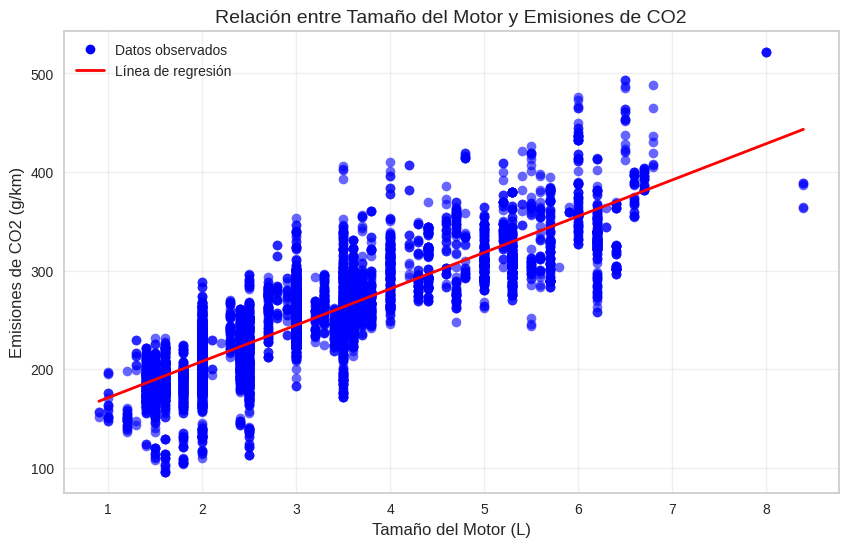

In [45]:
# Crear la gráfica de regresión con dos colores
plt.figure(figsize=(10, 6))
scatter = sns.regplot(x='engine_size', y='co2', data=df,
                      ci=None,
                      scatter_kws={'color': 'blue', 'alpha': 0.6},  # Color para los puntos
                      line_kws={'color': 'red', 'linewidth': 2})   # Color para la línea de regresión

# Añadir títulos y etiquetas
plt.title('Relación entre Tamaño del Motor y Emisiones de CO2', fontsize=14)
plt.xlabel('Tamaño del Motor (L)', fontsize=12)
plt.ylabel('Emisiones de CO2 (g/km)', fontsize=12)

# Añadir leyenda
plt.legend(handles=[plt.Line2D([], [], color='blue', marker='o', linestyle='', label='Datos observados'),
                    plt.Line2D([], [], color='red', linewidth=2, label='Línea de regresión')])

plt.grid(True, alpha=0.3)
plt.show()

Comentarios:
* En el gráfico, los puntos se alinean en torno a una línea recta. Esto sugiere que el modelo tiene un desempeño aceptable.
* Calcular y mostrar métricas como MAE, MSE o
𝑅
2
  para reforzar con números lo que se observa visualmente.
* Tener en cuenta que este tipo de análisis es opcional, y se puede realizar entre las variables predictoras (independientes) con relación a la variable a predecir (Objetivo) con el objetivo de visualizar cómo puede influir durante el entrenamiento.


# 3. PIPELINE/DIVISÓN DE DATOS
**EXPERIMENTO 1**

In [20]:
# Dividir la variable caractersiticas elegida como independiente y la variable objetivo para correr el algoritmo de Linear Regresssion
X = df[['engine_size']]
y = df['co2']

In [21]:
# train_test_split -> Sirve para dividir los datos en conjuntos de entrenamiento y prueba de forma aleatoria.
from sklearn.model_selection import train_test_split

#La función train_test_split(X, y, ...) divide estos datos en cuatro variables:
# X_train	80% de X	Para entrenar el modelo
# X_test	20% de X	Para evaluar el modelo
# y_train	80% de y	Las etiquetas de X_train
# y_test	20% de y	Las etiquetas de X_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Explicacion de Random State
# random_state fija la aleatoriedad en la división de datos.
# Permite obtener siempre la misma división al ejecutar el código.
# No tiene que ser 42, puedes usar cualquier número.
# Si no lo defines, cada vez que ejecutes el código, la división será diferente.

In [22]:
# Mostrar el tamaño de los DataSets Resultantes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5908, 1)
X_test shape: (1477, 1)
y_train shape: (5908,)
y_test shape: (1477,)


# 4. PIPELINE/SELECCIÓN Y CONSTRUCCIÓN DEL MÓDELO

In [23]:
# Utilizo la libreria de SKLearn para hacer el llamado del algortimo en especifico que nos sirve para aplicar regresiones.
from sklearn.linear_model import LinearRegression
model_simple_lin_reg = LinearRegression()

# 5. PIPELINE/ENTRENAR EL MÓDELO

In [24]:
# TIP TIP : Fit es el metodo que nos permite entrenar los datos que tenemos eligiendo previamente un model, notese que tomamos lo sets de entrenamiento
model_simple_lin_reg.fit(X_train, y_train)

LinearRegression()

# 6. PIPELINE/EVALUACIÓN DEL MÓDELO

In [25]:
# TIP TIP : Predict, Hace Predecciones usando el set de prueba
y_train_pred = model_simple_lin_reg.predict(X_train) # Datos conocidos
y_pred = model_simple_lin_reg.predict(X_test) # Datos no conocidos

Explicación y_train_pred:



*  Usamos el modelo ya entrenado para hacer predicciones en los mismos datos con los que aprendió (X_train).
*  y_train_pred contendrá los valores predichos para cada ejemplo en X_train.
* Podemos comparar estos valores con y_train (los valores reales) para ver qué tan bien aprendió el modelo.

Explicación y_pred:

* Usamos el modelo entrenado para predecir los valores de y para los datos nunca antes vistos (X_test).
* y_pred contendrá los valores predichos para cada ejemplo en X_test.
* Luego podemos comparar y_pred con y_test (los valores reales) para evaluar qué tan bien generaliza el modelo en nuevos datos.







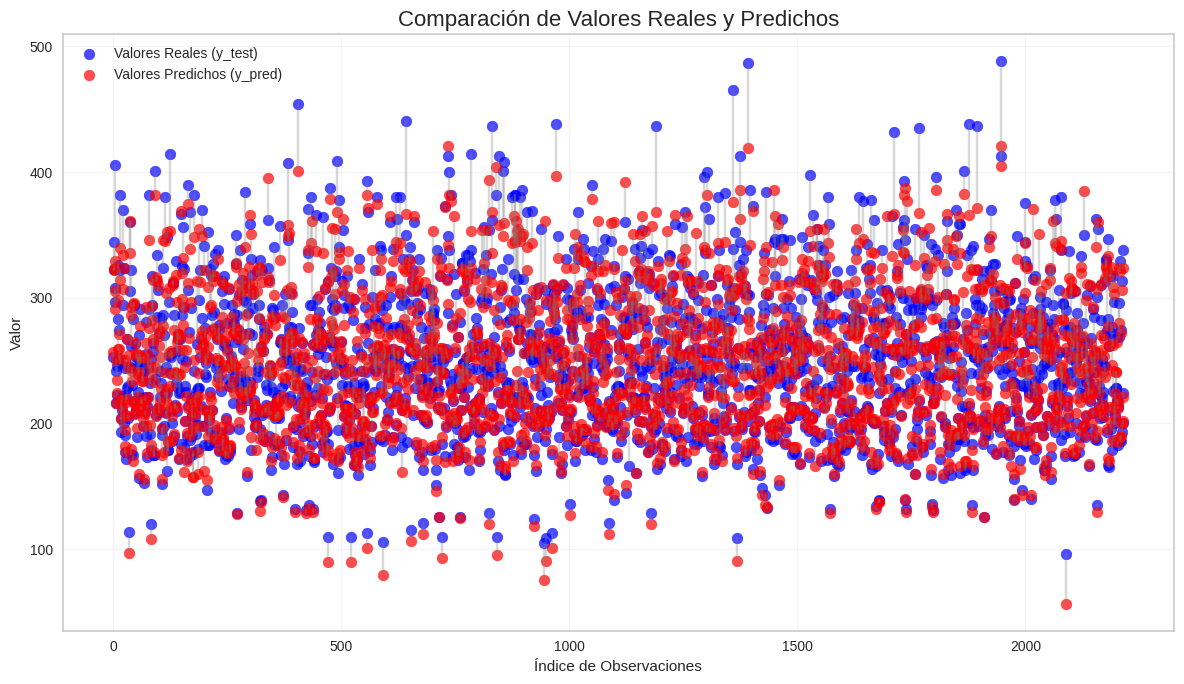

In [49]:
plt.figure(figsize=(12, 7))

# Convertir a arrays numpy si no lo están ya
y_test_array = np.array(y_test).flatten()
y_pred_array = np.array(y_pred).flatten()

# Crear un rango de índices
index = np.arange(len(y_test_array))

# Graficar
plt.scatter(index, y_test_array, color='blue', alpha=0.7, label='Valores Reales (y_test)', s=60)
plt.scatter(index, y_pred_array, color='red', alpha=0.7, label='Valores Predichos (y_pred)', s=60)

# Conectar los puntos
for i in range(len(y_test_array)):
    plt.plot([index[i], index[i]], [y_test_array[i], y_pred_array[i]], 'gray', alpha=0.3)

# Personalización
plt.title('Comparación de Valores Reales y Predichos', fontsize=16)
plt.xlabel('Índice de Observaciones')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [50]:
my_dict = {"Actual": y_test, "pred": y_pred, "residual": y_test - y_pred}
compare = pd.DataFrame(my_dict)
compare

,Actual,pred,residual
7261,253,257.031262,-4.031262
4489,344,322.497210,21.502790
1539,322,323.265150,-1.265150
3532,297,305.074061,-8.074061
6418,308,291.303823,16.696177
...,...,...,...
5123,313,305.977511,7.022489
5359,193,199.396333,-6.396333
7294,200,202.154228,-2.154228
2569,224,221.042482,2.957518


In [51]:
# Exportar el DataFrame a un archivo CSV
compare.to_csv('comparacion_predicciones.csv', index=False)

# Evaluar el Módelo con métricas de Performance

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_val(y_train, y_train_pred, y_test, y_pred, i):

    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},

    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }

    return pd.DataFrame(scores)

In [29]:
slr_score = train_val(y_train, y_train_pred, y_test, y_pred, 'linear')
slr_score

,linear_train,linear_test
R2,0.724528,0.723812
mae,23.374987,22.927177
mse,941.716358,949.985253
rmse,30.687397,30.821831


# Ahora entendamos que quieren decir estas métricas:

# **R 2 -> (Coeficiente de determinación)**

Valor:
Entrenamiento: 0.7245
Prueba: 0.7238
Interpretación:
Este valor mide qué proporción de la variabilidad en el conjunto de datos está explicada por el modelo. Un 𝑅2
cercano a 1 indica un modelo que explica bien los datos; un valor cercano a 0 indica que el modelo no logra capturar la relación entre las variables.
En este caso, el modelo está explicando aproximadamente el 72.4% de la variabilidad en los datos, tanto en el conjunto de entrenamiento como en el de prueba. Esto indica que el modelo tiene un buen ajuste, pero no es perfecto.

# **MAE (Error absoluto medio)**

Valor:
Entrenamiento: 23.37
Prueba: 22.93
Interpretación:
El MAE mide el error promedio entre las predicciones del modelo y los valores reales. Es fácil de interpretar porque está en las mismas unidades que la variable objetivo.
Un error promedio de alrededor de 23 significa que, en promedio, el modelo se desvía 23 unidades del valor real.
* Dado que el MAE es similar en entrenamiento y prueba, esto sugiere nuevamente que el modelo está generalizando bien.

# **MSE (Error cuadrático medio)**
Valor:
Entrenamiento: 941.72
Prueba: 949.99
Interpretación:
El MSE mide el promedio de los errores al cuadrado. Penaliza errores grandes más que el MAE, lo que lo hace más sensible a valores atípicos.
Aunque es más difícil de interpretar directamente (ya que está en unidades al cuadrado), es útil para detectar si el modelo está cometiendo grandes errores.

* El MSE entre entrenamiento y prueba es consistente, lo cual refuerza la idea de que el modelo no está sobreajustando ni subajustando.

# **RMSE (Raíz del error cuadrático medio)**
Valor:
Entrenamiento: 30.69
Prueba: 30.82
Interpretación:
El RMSE es la raíz cuadrada del MSE, lo que lo convierte en una métrica en las mismas unidades que la variable objetivo, facilitando su interpretación.
Un RMSE de aproximadamente 30 significa que, en promedio, el modelo tiene un error de predicción de 30 unidades.

* Dado que el RMSE es mayor que el MAE, esto indica que hay algunos errores más grandes que están influyendo en la métrica.

# **EN GENERAL**

* Las métricas son similares en ambos conjuntos, lo cual es una señal de que el modelo no está sobreajustando ni subajustando. Esto es ideal para un modelo bien entrenado.

# Aunque el modelo tiene un desempeño razonable, todavía hay un margen para reducir los errores (MAE, MSE, RMSE). Esto podría lograrse mediante:
* Ajuste de hiperparámetros.
* Inclusión de más variables predictoras relevantes.
* Transformaciones en los datos.

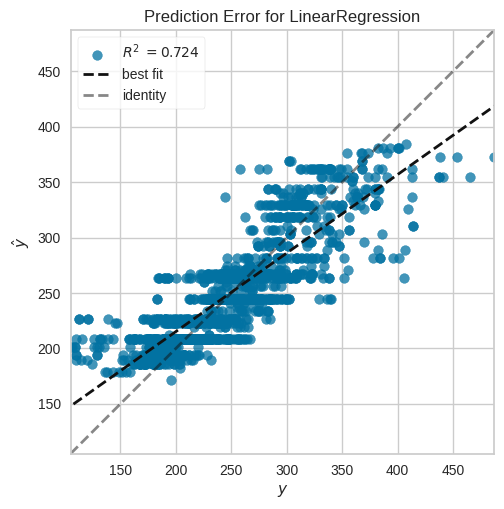

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [30]:
from yellowbrick.regressor import PredictionError

model = LinearRegression()

visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)  # Mostrar los datos de prueba
visualizer.score(X_test, y_test)  # Evaluar el modelo en estos datos de prueba
visualizer.show()                 # Mostrar la gráfica

# Aplicar Algoritmo de Linear Regression (Ejercicio que hace uso de varias variables independientes para predecir)
**EXPERIMENTO 2 - POR CADA EXPERIMENTO NUEVO REPETIR LOS PASOS QUE 3,4,5,6**

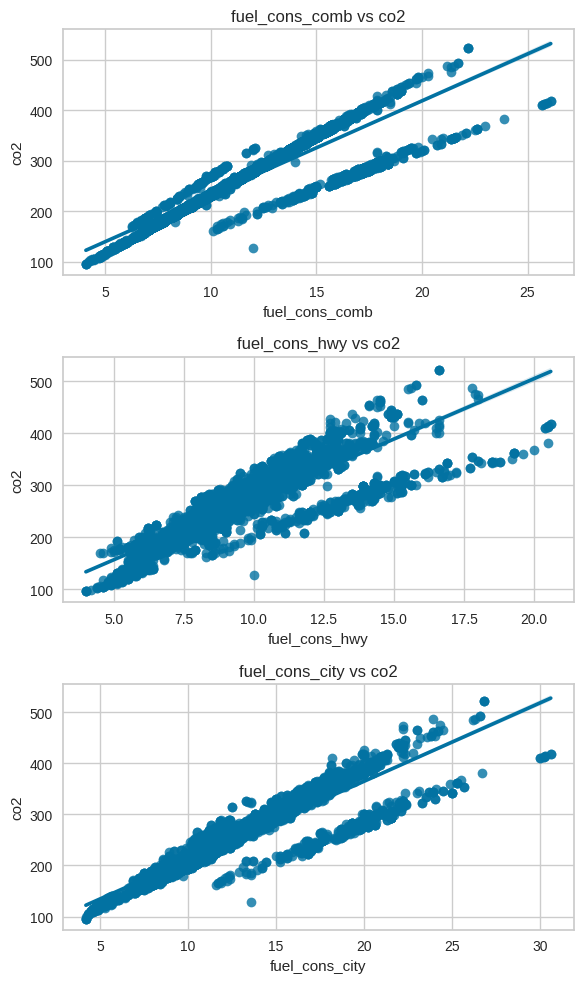

In [57]:
# Ver la relación entre las caracteristicas independientes y la variable objetivo (dependiente)
independent_variables = ['fuel_cons_comb', 'fuel_cons_hwy','fuel_cons_city' ]
target_variable = 'co2'

plt.figure(figsize=(6,10))

for i, var in enumerate(independent_variables):
    plt.subplot(3,1, i + 1)
    sns.regplot(x=df[var], y=df[target_variable])
    plt.title(f'{var} vs {target_variable}')

plt.tight_layout()
plt.show()

In [58]:
# Dividir la Data, entre la función objetivo y el resto de los datos
X = df[["engine_size", "cylinders", "fuel_cons_comb", "fuel_cons_comb_mpg"]]
y = df["co2"]

In [59]:
X.head()

,engine_size,cylinders,fuel_cons_comb,fuel_cons_comb_mpg
0,2.0,4,8.5,33
1,2.4,4,9.6,29
2,1.5,4,5.9,48
3,3.5,6,11.1,25
4,3.5,6,10.6,27


In [60]:
# Dividir el set de datos de pruebas y el set de datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [61]:
# Mostrar como se ha definido la distribución de Datos
print("Tamaño de la muestra incluida en el set de entrenamiento: {}\ny Tamaño de la muestra de entrenamiento: {}\nX Tamaño de la muestra que se incluye en el set de testing: {}\ny Tamaño de la muestra usada en prueba: {}"
      .format(X_train.shape, y_train.shape, X_test.shape, y_test.shape))

Tamaño de la muestra incluida en el set de entrenamiento: (5169, 4)
y Tamaño de la muestra de entrenamiento: (5169,)
X Tamaño de la muestra que se incluye en el set de testing: (2216, 4)
y Tamaño de la muestra usada en prueba: (2216,)


# Definición del Módelo

In [62]:
model_multi_lin_reg = LinearRegression()

# Entrenar el Módelo

In [63]:
model_multi_lin_reg.fit(X_train, y_train)

LinearRegression()

# Predicting Test Data

In [64]:
y_pred = model_multi_lin_reg.predict(X_test)
y_train_pred = model_multi_lin_reg.predict(X_train)

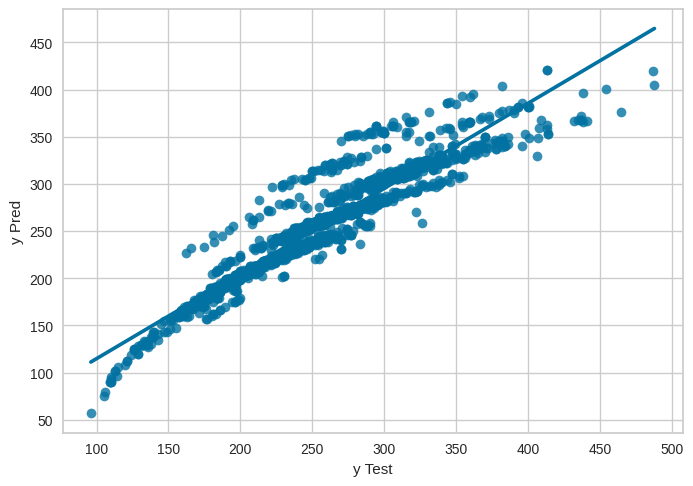

In [65]:
# Gráficar el comportamiento de la predicción y su ajuste frente al módelo lineal
sns.regplot(x=y_test, y=y_pred, ci=None)
plt.xlabel('y Test')
plt.ylabel('y Pred')
plt.show()

In [66]:
# Se imprimen las predicciones del modelo y se empiezan analizar los residuos obtenidos
my_dict = {"Actual": y_test, "pred": y_pred, "residual": y_test - y_pred}
compare = pd.DataFrame(my_dict)
compare

,Actual,pred,residual
7261,253,257.031262,-4.031262
4489,344,322.497210,21.502790
1539,322,323.265150,-1.265150
3532,297,305.074061,-8.074061
6418,308,291.303823,16.696177
...,...,...,...
5123,313,305.977511,7.022489
5359,193,199.396333,-6.396333
7294,200,202.154228,-2.154228
2569,224,221.042482,2.957518


# Ahora hagamos algunas Predicciones individuales

In [70]:
def hacer_prediccion_individual(modelo, engine_size, cylinders, fuel_comb, fuel_comb_mpg):
    """
    Función para hacer predicciones individuales de emisiones de CO2

    Parámetros:
    -----------
    modelo: Modelo de ML ya entrenado
    engine_size: Tamaño del motor en litros
    cylinders: Número de cilindros
    fuel_comb: Consumo de combustible combinado (L/100km)
    fuel_comb_mpg: Consumo de combustible combinado (millas por galón)

    Retorna:
    --------
    Predicción de emisiones de CO2 (g/km)
    """
    # Crear un DataFrame con los valores de entrada
    datos_entrada = pd.DataFrame({
        'engine_size': [engine_size],
        'cylinders': [cylinders],
        'fuel_cons_comb': [fuel_comb],
        'fuel_cons_comb_mpg': [fuel_comb_mpg]
    })

    # Hacer la predicción
    prediccion = modelo.predict(datos_entrada)

    return round(prediccion[0], 2)  # Devolver el valor redondeado a 2 decimales

In [72]:
# 2. Hacer una predicción
emisiones = hacer_prediccion_individual(
    modelo=model_multi_lin_reg,
    engine_size=2.4,
    cylinders=4,
    fuel_comb=9.2,
    fuel_comb_mpg=31
)

if emisiones is not None:
    print(f"Emisiones predichas: {emisiones} g CO2/km")

Emisiones predichas: 213.99 g CO2/km


# Evaluar Performance - Métricas

In [41]:
def train_val(y_train, y_train_pred, y_test, y_pred, i):

    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},

    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }

    return pd.DataFrame(scores)

In [42]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "multi")
mlr_score

,multi_train,multi_test
R2,0.903877,0.900108
mae,11.436689,11.514614
mse,330.829164,337.406607
rmse,18.188710,18.368631


# Conclusiones

El módelo tiene un coeficiente de determinación mas alto cuando solo se incluyen las cuatro caracteristicas numéricas, a continuación se muestra que la predicción del módelo se encuentra muy ajustada  al mejor fit de predicción de los datos.

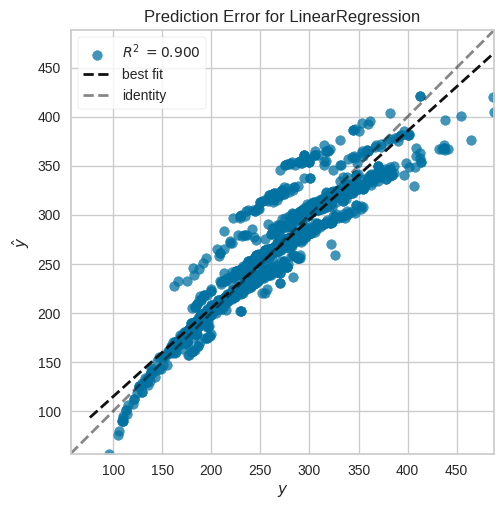

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [43]:
from yellowbrick.regressor import PredictionError

model = LinearRegression()

visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)  # Mostrar los datos de prueba
visualizer.score(X_test, y_test)  # Evaluar el modelo en estos datos de prueba
visualizer.show()                 # Mostrar la gráfica

# Aplicar Algoritmo Random Forest (Ejercicio que hace uso de varias variables independientes para predecir)
**EXPERIMENTO 3 - POR CADA EXPERIMENTO NUEVO REPETIR LOS PASOS QUE 4,5,6**

In [78]:
# Ver la relación entre las caracteristicas independientes y la variable objetivo (dependiente)
independent_variables = ['fuel_cons_comb', 'fuel_cons_hwy','fuel_cons_city' ]
target_variable = 'co2'

In [79]:
# Dividir la Data, entre la función objetivo y el resto de los datos
X = df[["engine_size", "cylinders", "fuel_cons_comb", "fuel_cons_comb_mpg"]]
y = df["co2"]

In [89]:
# Dividir el set de datos de pruebas y el set de datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [90]:
 rf_model = RandomForestRegressor(
    n_estimators=100,  # Número de árboles en el bosque
    random_state=42,    # Semilla para reproducibilidad
    max_depth=10,       # Profundidad máxima de los árboles
    min_samples_split=5 # Mínimo número de muestras para dividir un nodo
)


In [84]:
rf_model .fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=5, random_state=42)

In [85]:
y_pred = rf_model .predict(X_test)
y_train_pred = rf_model .predict(X_train)

In [86]:
# Se imprimen las predicciones del modelo y se empiezan analizar los residuos obtenidos
my_dict = {"Actual": y_test, "pred": y_pred, "residual": y_test - y_pred}
compare = pd.DataFrame(my_dict)
compare

,Actual,pred,residual
7261,253,253.425957,-0.425957
4489,344,341.746297,2.253703
1539,322,327.368520,-5.368520
3532,297,295.696691,1.303309
6418,308,309.418629,-1.418629
...,...,...,...
5123,313,310.548238,2.451762
5359,193,192.585976,0.414024
7294,200,199.868656,0.131344
2569,224,223.542758,0.457242


In [87]:
def train_val(y_train, y_train_pred, y_test, y_pred, i):

    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},

    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }

    return pd.DataFrame(scores)


In [88]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "multi")
mlr_score

,multi_train,multi_test
R2,0.988390,0.968800
mae,2.920558,4.167593
mse,39.958350,105.385797
rmse,6.321262,10.265758
